In [1]:
import os
import cv2
import json
# from io import BytesIO
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder

import scipy
import cv2
from skimage.measure import regionprops, label, shannon_entropy
from skimage.transform import resize
from skimage.color import rgb2gray
from skimage import img_as_ubyte
from brisque import BRISQUE
from skvideo.measure import niqe
from pypiqe import piqe
from mahotas.features import zernike_moments
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

import torch
from torch import nn
from torch.utils.data import Dataset
from torchvision import transforms
import timm
import segmentation_models_pytorch as smp

from pytorch_grad_cam import FinerCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# Patch imresize if missing
if not hasattr(scipy.misc, "imresize"):
    def imresize(arr, size, interp=None, mode=None):
        if isinstance(size, float):  # scale factor
            new_shape = (int(arr.shape[0] * size), int(arr.shape[1] * size))
        else:
            new_shape = size[:2]
        arr_resized = resize(arr, new_shape, order=3, mode="reflect", anti_aliasing=True)
        arr_resized = (arr_resized * 255).astype(np.uint8)
        return arr_resized
    scipy.misc.imresize = imresize

# Patch for deprecated NumPy aliases (for backward compatibility)
if not hasattr(np, 'int'):
    np.int = int
if not hasattr(np, 'float'):
    np.float = float
if not hasattr(np, 'bool'):
    np.bool = bool

/tmp/ipykernel_1970839/1780638934.py:53: FutureWarning: In the future `np.bool` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, 'bool'):


In [2]:
# Hyperparameters and paths
DATA_DIR = r"/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v5/"
CLASS_NAMES = os.listdir(DATA_DIR)
NUM_CLASSES = len(CLASS_NAMES)
NUM_PARTS = 4
CLASSIFIER_NAME = "deit_base_distilled_patch16_224.fb_in1k"
SEGMENTATION_NAME = "deeplabv3plus"
SEGMENTATION_ENCODER = "resnext50_32x4d"
CLASSIFIER_WEIGHTS = r"/home/c/choton/beemachine/codes/AG_vision_2026/classification/Beemachine/convnext_nano.in12k_timm_new_dataset_logs/checkpoints/best_model.pth"
SEGMENTATION_WEIGHTS = r"/home/c/choton/beemachine/codes/AG_vision_2026/2_segmentation/Beemachine/deeplabv3+/lightning_logs/version_0/checkpoints/epoch=199-step=54400.ckpt"
# SHAPE_FEATS_PATH = r"/home/c/choton/beemachine/codes/everyday_test/November_25/Nov12_25/shape_features/beemachine_small_2025_part_features.csv"
FEATURE_SIZE = 937
IMAGE_SIZE = 224
DEVICE_ID = 0

# Load the train and validation dataset
train_datapath = os.path.join(DATA_DIR, 'train_aug_labels.csv')
val_datapath = os.path.join(DATA_DIR, 'val_labels.csv')
test_datapath = os.path.join(DATA_DIR, 'test_labels.csv')

train_df = pd.read_csv(train_datapath) 
val_df = pd.read_csv(val_datapath) 
test_df = pd.read_csv(test_datapath)

le = LabelEncoder()
train_df["label"] = le.fit_transform(train_df["species"])
val_df["label"] = le.transform(val_df["species"])
test_df["label"] = le.transform(test_df["species"])
num_classes = len(le.classes_)
print(f"Total images, Train: {len(train_df['label'])}, Validation: {len(val_df['label'])}, Test: {len(test_df['label'])}")
print(f"Total classes: {num_classes}")

train_path = os.path.join(DATA_DIR, "train", 'aug_images') # Path for the training data
val_path = os.path.join(DATA_DIR, "valid", 'images') # Path for validation data
test_path = os.path.join(DATA_DIR, "test", 'images') # Path for testing data

Total images, Train: 34722, Validation: 1158, Test: 771
Total classes: 160


In [3]:
class SpeciesDataset(Dataset):
    def __init__(self, df, img_dir, image_size):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.4925, 0.4475, 0.3490), # Custom normalization values for beemachine_small_2025_v3 (segmentation) dataset
                             std=(0.2392, 0.2265, 0.2213))
        # transforms.Normalize(mean=[0.485, 0.456, 0.406], # Imagenet Normalization values
        #              std=[0.229, 0.224, 0.225])
    ])
        self.num_classes = self.df["label"].nunique()
        
    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.loc[idx, "image"]
        label = self.df.loc[idx, "label"]

        img_path = os.path.join(self.img_dir, img_name)
        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, label, img_path

In [4]:
train_dataset = SpeciesDataset(df=train_df, img_dir=train_path, image_size=IMAGE_SIZE)
val_dataset = SpeciesDataset(df=val_df, img_dir=val_path, image_size=IMAGE_SIZE)
test_dataset = SpeciesDataset(df=test_df, img_dir=test_path, image_size=IMAGE_SIZE)

num_classes = train_dataset.num_classes
print(f"Classes: {num_classes} | Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Classes: 160 | Train: 34722 | Val: 1158 | Test: 771


In [5]:
# Create SIFT and ORB detectors once
sift = cv2.SIFT_create()
orb = cv2.ORB_create()
bri_obj = BRISQUE(url=False)

def extract_base_features(mask):
    """Compute geometric, Zernike, Fourier, and texture shape descriptors from a binary mask."""
    
    features = ["area", "perimeter", "aspect_ratio", "extent", "solidity", "eccentricity", 
        "orientation", "circularity", "elongation", "compactness"]
    
    if mask is None or mask.sum() == 0:
        return {f: 0 for f in features}

    # --- Region properties ---
    # mask = mask.astype(np.uint8)
    labeled = label(mask)
    props = regionprops(labeled)
    if len(props) == 0:
        return {f: 0 for f in features}
    p = props[0]
    major_axis = p.major_axis_length
    minor_axis = p.minor_axis_length

    # ----- base shape features -----
    area = p.area
    perimeter = max(p.perimeter, 1e-6) # Ignoring too small perimeters
    aspect_ratio = major_axis / minor_axis if minor_axis > 0 else 0 # L_major / L_minor
    extent = p.extent
    solidity = p.solidity
    eccentricity = p.eccentricity
    orientation = p.orientation
    circularity = 4 * np.pi * area / (perimeter ** 2)
    elongation = 1 - (minor_axis / major_axis) if major_axis > 0 else 0
    # convexity = p.perimeter_convex / perimeter
    compactness = (perimeter ** 2) / (4 * np.pi * area + 1e-6)

    # ----- Assemble features -----
    features_d = {
        "area": area,
        "perimeter": perimeter,
        "aspect_ratio": aspect_ratio,
        "extent": extent,
        "solidity": solidity,
        "eccentricity": eccentricity,
        "orientation": orientation,
        "circularity": circularity,
        "elongation": elongation,
        "compactness": compactness
    }
    return features_d

def compute_sift_features(image, mask=None):
    # if isinstance(image, torch.Tensor):
    #     image = image.detach().cpu().numpy().transpose(1, 2, 0) # Transform tensor to numpy image
    # if isinstance(mask, torch.Tensor):
    #     mask = mask.numpy().astype(np.uint8)
    gray= cv2.cvtColor(img_as_ubyte(image), cv2.COLOR_RGB2GRAY) # converts image into uint8 and mask as input
    keypoints, descriptors = sift.detectAndCompute(gray, mask)
    if descriptors is None:
        descriptors = np.full((0, 128), np.nan, dtype=np.float32)  # return empty array if no keypoints
    return keypoints, descriptors

def compute_orb_features(image, mask=None):
    # if isinstance(image, torch.Tensor):
    #     image = image.detach().cpu().numpy().transpose(1, 2, 0) # Transform tensor to numpy image
    # if isinstance(mask, torch.Tensor):
    #     mask = mask.numpy().astype(np.uint8)
    gray= cv2.cvtColor(img_as_ubyte(image), cv2.COLOR_RGB2GRAY)
    keypoints, descriptors = orb.detectAndCompute(gray, mask)
    if descriptors is None:
        descriptors = np.full((0, 32), np.nan, dtype=np.float32)  # return empty array if no keypoints
    return keypoints, descriptors

def compute_hu_moments(mask):
    # if not isinstance(mask, np.ndarray):
    #     mask = mask.numpy().astype(np.uint8)
    moments = cv2.moments(mask)
    hu = cv2.HuMoments(moments).flatten()
    hu = np.log(np.abs(hu) + 1e-12) # log-scale for stability
    return hu

def compute_zernike_moments(mask, degree=8):
    # if not isinstance(mask, np.ndarray):
    #     mask = mask.numpy().astype(np.uint8)
    radius = min(mask.shape) // 2
    mask_norm = mask / mask.max() if mask.max() > 0 else mask
    zern = zernike_moments(mask_norm, radius=radius, degree=degree)
    return zern

# *** Updated fourier descriptors (Dec 4, 2025)
def compute_fourier_descriptors(mask, image=None, fourier_harmonics=20, visualize=False):
    if not isinstance(mask, np.ndarray): # Ensure proper mask format
        mask = mask.numpy().astype(np.uint8)
    # --- 2. Find largest contour (object part) ---
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not contours:
        return np.full(fourier_harmonics, np.nan, dtype=np.float32)
    cnt = max(contours, key=cv2.contourArea)
    if len(cnt) < 3:
        # Too few points for Fourier transform
        return np.full(fourier_harmonics, np.nan, dtype=np.float32)
    
    # Translation invariance: center contour
    complex_contour = cnt[:,0,0] + 1j * cnt[:,0,1]
    fd = np.fft.fft(complex_contour)
    
    if visualize: # ** IMPORTANT: Visualization uses raw contour (so you can see the real shape), descriptors are centered.
        # Convert image if needed
        H, W = mask.shape
        if image is not None:
            if isinstance(image, torch.Tensor):
                image = image.detach().cpu().numpy().transpose(1, 2, 0)
            elif isinstance(image, Image.Image):
                image = np.array(image.convert('RGB'))
            elif image.dtype != np.uint8:  # NumPy float → uint8
                image = (image*255).astype(np.uint8)
            img_draw = image.copy()
        else:
            img_draw = np.zeros((H, W, 3), dtype=np.uint8)
        cv2.drawContours(img_draw, [cnt.astype(np.int32)], -1, (0, 255, 0), 2)

        fd_recon = fd.copy()
        keep = fourier_harmonics
        if 2 * keep < len(fd_recon):
            fd_recon[keep:-keep] = 0 # Safe zeroing
        else:
            fd_recon[keep:] = 0
        recon = np.fft.ifft(fd_recon)
        pts = np.column_stack((recon.real, recon.imag)).astype(np.int32)

        for i in range(len(pts)):
            cv2.line(img_draw, tuple(pts[i]), tuple(pts[(i + 1) % len(pts)]), (255, 0, 255), 1)
        plt.figure(figsize=(16, 6))
        plt.imshow(img_draw)
        plt.axis('off')
        plt.title("Shape Descriptors Overlay")
        plt.legend(
            handles=[
                Patch(facecolor='green', edgecolor='green'),
                Patch(facecolor='magenta', edgecolor='magenta')
            ],
            labels=["Contour", "Fourier Reconstruction"],
            loc='upper right'
        )
        plt.show()
    
    cnt_centered = complex_contour - np.mean(complex_contour)
    fd = np.fft.fft(cnt_centered)
    if len(fd) < 2 or np.abs(fd[1]) == 0:
        return np.full(fourier_harmonics, np.nan, dtype=np.float32)

    # Scale invariance: divide by first descriptor magnitude
    fd = fd / np.abs(fd[1])

    # Rotation invariance: use only magnitudes
    fd_normalized = np.abs(fd)

    # Keep only first N harmonics
    fd_truncated = fd_normalized[:fourier_harmonics]
    if len(fd_truncated) < fourier_harmonics:
        fd_truncated = np.concatenate([fd_truncated, np.full((fourier_harmonics - len(fd_truncated)), np.nan)])
    return fd_truncated

def extract_shape_features(image, mask):
    # Compute base features
    features = extract_base_features(mask)

    # Compute sift features
    sift_kp, sift_ds = compute_sift_features(image, mask)
    sift_sizes = [k.size for k in sift_kp]
    if sift_ds.shape[0] > 0:
        sift_mean_ds = np.nanmean(sift_ds, axis=0)
    else:
        sift_mean_ds = np.full(128, np.nan)
    sift_dict = {f'sift_ds{i+1}': sift_mean_ds[i] for i in range(len(sift_mean_ds))}
    sift_dict['sift_kp_n'] = len(sift_kp)
    sift_dict['sift_kp_size'] = np.max(sift_sizes) if sift_sizes else 0

    # Compute orb features
    orb_kp, orb_ds = compute_orb_features(image, mask)
    if orb_ds.shape[0] > 0:
        orb_mean_ds = np.nanmean(orb_ds, axis=0)
    else:
        orb_mean_ds = np.full(32, np.nan)
    orb_dict = {f'orb_ds{i+1}': orb_mean_ds[i] for i in range(len(orb_mean_ds))}
    orb_dict['orb_kp_n'] = len(orb_kp)

    # Compute hu moments
    hu_moments = compute_hu_moments(mask)
    hu_dict = {f"hu{i+1}": hu_moments[i] for i in range(len(hu_moments))}

    # Compute Zernike moments
    zern_moments = compute_zernike_moments(mask, degree=8)
    zern_dict = {f"zernike_{i+1}": zern_moments[i] for i in range(len(zern_moments))}

    # Compute fourier descriptors
    fourier_ds = compute_fourier_descriptors(mask, fourier_harmonics=20)
    fourier_dict = {f"fourier_{i+1}": fourier_ds[i] for i in range(len(fourier_ds))}

    features.update(sift_dict)
    features.update(orb_dict)
    features.update(hu_dict)
    features.update(zern_dict)
    features.update(fourier_dict)
    converted = {k: np.float32(v) for k, v in features.items()}
    return converted

def extract_visual_features(image, mask):
    # --- 1. Ensure binary uint8 mask ---
    if not isinstance(mask, np.ndarray):
        mask = mask.numpy().astype(np.uint8)
    # Convert image to numpy
    if isinstance(image, torch.Tensor):
        image = image.detach().cpu().numpy().transpose(1, 2, 0)
    elif isinstance(image, Image.Image):
        image = np.array(image.convert('RGB'))
    img_cropped = np.zeros_like(image)
    img_cropped[mask==1] = image[mask==1]
    # plt.imshow(img_cropped)

    # --- Brightness ---
    brightness = np.mean(img_cropped)

    # --- Contrast (standard deviation of luminance) ---
    gray = rgb2gray(img_cropped)
    contrast = np.std(gray)

    # --- Sharpness (variance of Laplacian) ---
    gray_8u = (gray * 255).astype(np.uint8)
    lap_var = cv2.Laplacian(gray_8u, cv2.CV_64F).var()

    # --- Colorfulness (Hasler & Süsstrunk, 2003) ---
    (R, G, B) = cv2.split(img_cropped)
    rg = np.abs(R - G)
    yb = np.abs(0.5 * (R + G) - B)
    std_rg, std_yb = np.std(rg), np.std(yb)
    mean_rg, mean_yb = np.mean(rg), np.mean(yb)
    colorfulness = np.sqrt(std_rg**2 + std_yb**2) + 0.3 * np.sqrt(mean_rg**2 + mean_yb**2)

    # --- Entropy (texture complexity) ---
    entropy = shannon_entropy(gray)

    # BRISQUE
    bri_obj = BRISQUE(url=False)
    brisque_score = bri_obj.score(img_cropped)

    # NIQE
    niqe_score = niqe(gray)

    # PIQE
    piqe_score, activityMask, noticeableArtifactMask, noiseMask = piqe(gray)

    # --- Aggregate descriptors ---
    descriptors = {
        "brightness": np.float32(brightness),
        "contrast": np.float32(contrast),
        "sharpness": np.float32(lap_var),
        "colorfulness": np.float32(colorfulness),
        "entropy": np.float32(entropy),
        "brisque": np.float32(brisque_score),
        "niqe": np.float32(niqe_score.item()),
        "piqe": np.float32(piqe_score)
    }
    return descriptors

def extract_combined_features(image, mask): 
    # ---- Convert once ----
    if isinstance(image, torch.Tensor):
        image = image.detach().cpu().numpy().transpose(1, 2, 0)
    if isinstance(image, Image.Image):
        image = np.asarray(image)
    if isinstance(mask, torch.Tensor):
        mask = mask.detach().cpu().numpy().astype(np.uint8)
    mask_u8 = mask.astype(np.uint8)
    image_f = (image - image.min()) / (image.max() - image.min() + 1e-8) # Linearly rescale to [0, 1] and avoid division by zero
    image_u8 = img_as_ubyte(image_f)

    combined_features = extract_shape_features(image_u8, mask_u8)
    vis_features = extract_visual_features(image_f, mask_u8)
    combined_features.update(vis_features)
    return combined_features

def extract_all_features(image, mask):
    abdomen_mask = mask == 1
    head_mask = mask == 2
    thorax_mask = mask == 3
    full_mask = mask > 0

    head_feats = extract_combined_features(image, head_mask)
    thorax_feats = extract_combined_features(image, thorax_mask)
    abdomen_feats = extract_combined_features(image, abdomen_mask)
    body_feats = extract_combined_features(image, full_mask)

    # Ratios
    area_sum = head_feats["area"] + thorax_feats["area"] + abdomen_feats["area"]
    ratios = {
        "head_to_thorax_area": head_feats["area"] / (thorax_feats["area"] + 1e-6),
        "thorax_to_abdomen_area": thorax_feats["area"] / (abdomen_feats["area"] + 1e-6),
        "head_to_total_area": head_feats["area"] / (area_sum + 1e-6),
        "thorax_to_total_area": thorax_feats["area"] / (area_sum + 1e-6),
        "abdomen_to_total_area": abdomen_feats["area"] / (area_sum + 1e-6),
    }

    record = {}
    record.update({f"head_{k}": v for k, v in head_feats.items()})
    record.update({f"thorax_{k}": v for k, v in thorax_feats.items()})
    record.update({f"abdomen_{k}": v for k, v in abdomen_feats.items()})
    record.update({f"full_{k}": v for k, v in body_feats.items()})
    record.update(ratios)
    return record

In [6]:
# Load classifier
def load_classifier(name, weights, num_classes, device_id):
    # Define the classification model and load weights
    model = timm.create_model(name, pretrained=False, num_classes=num_classes).to(f"cuda:{device_id}")
    state_dict_c = torch.load(weights, map_location=f"cuda:{device_id}")
    model.load_state_dict(state_dict_c) # Load the classifier state dict
    return model

# Load segmentation model
def load_segmentation(name, encoder_name, checkpoint_path):    
    # Define the segmentation model and load weights
    model = smp.create_model(
                name,
                encoder_name=encoder_name,
                in_channels = 3, # 3 for RGB images
                classes = NUM_PARTS
            ).to(f"cuda:{DEVICE_ID}")
    # checkpoint_path = r"/home/c/choton/beemachine/codes/everyday_test/oct1_25/segmentation_models/lightning_logs/fpn/lightning_logs/version_0/checkpoints/epoch=199-step=37400.ckpt"
    checkpoint = torch.load(checkpoint_path, map_location=rf"cuda:{DEVICE_ID}")

    # Sometimes Lightning adds "state_dict"
    if "state_dict" in checkpoint:
        state_dict = checkpoint["state_dict"]

        # Remove "model." or "net." prefixes if present
        new_state_dict = {k.replace("model.", "").replace("net.", ""): v 
                        for k, v in state_dict.items() if k not in ["mean", "std"]}

        model.load_state_dict(new_state_dict)
    else:
        model.load_state_dict(checkpoint)
    # model.to(f"cuda:{DEVICE_ID}")
    return model

In [7]:
class ShapeEncoder(nn.Module):
    def __init__(self, embed_dim=256):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d(1)
        )

        self.fc = nn.Linear(128, embed_dim)

    def forward(self, mask_tensor):
        """
        mask_tensor: (B, 3, 64, 64)
        """
        feat = self.encoder(mask_tensor)
        feat = feat.flatten(1)
        z = self.fc(feat)
        return z  

class GatedFusion(nn.Module):
    def __init__(self, img_dim, shape_dim):
        super().__init__()

        self.shape_proj = nn.Linear(shape_dim, img_dim)

        self.gate = nn.Sequential(
            nn.Linear(img_dim + img_dim, img_dim),
            nn.LayerNorm(img_dim),
            nn.Sigmoid()
        )

    def forward(self, z_img, z_shape):
        z_shape_proj = self.shape_proj(z_shape)

        concat = torch.cat([z_img, z_shape_proj], dim=1)
        g = self.gate(concat)

        fused = z_img + g * (z_shape_proj - z_img)
        return fused

class DeepShapeFusionModel(nn.Module):
    def __init__(self, num_classes, shape_embed_dim=256):
        super().__init__()
        self.num_shape_feats = FEATURE_SIZE

        # Modules
        self.seg_module = load_segmentation(
            name=SEGMENTATION_NAME, 
            encoder_name=SEGMENTATION_ENCODER, 
            checkpoint_path=SEGMENTATION_WEIGHTS
        )
        self.backbone = timm.create_model(model_name=CLASSIFIER_NAME, pretrained=True, num_classes=0)
        self.shape_encoder = ShapeEncoder(shape_embed_dim)
        self.feature_dim = self.backbone.num_features

        self.fusion = GatedFusion(
            img_dim=self.backbone.num_features,
            shape_dim=shape_embed_dim
        )
        self.global_pool = nn.AdaptiveAvgPool2d(1)

        total_feats = self.backbone.num_features # + self.num_shape_feats # + shape_embed_dim

        self.classifier = nn.Sequential(
                                nn.LayerNorm(total_feats),
                                nn.Dropout(0.3),
                                nn.Linear(total_feats, num_classes)
                            )

        for p in self.seg_module.parameters():
            p.requires_grad = False
        self.seg_module.eval()

    def forward(self, x, shape_feats=None):

        # ---- Segmentation ----
        with torch.no_grad():
            mask_logits = self.seg_module(x)
            masks = torch.argmax(mask_logits, dim=1)  # (B, H, W) with labels 0,1,2,3
        # mask_logits = self.seg_module(x)
        # mask_probs = torch.softmax(mask_logits, dim=1)  # example single part

        # Extract part embeddings
        parts = mask_logits[:, 1:, :, :]  # remove background, will try mask_probs as well
        mask_binary = parts.sum(dim=1, keepdim=True)
        edge = torch.abs(
            torch.nn.functional.avg_pool2d(mask_binary, 3, stride=1, padding=1)
            - mask_binary
        )
        shape_tensor = torch.cat([mask_binary, edge, mask_binary], dim=1)
        z_shape = self.shape_encoder(shape_tensor)

        # ---- Extract hand-crafted shape descriptors ----
        # ---- Shape features ----
        if shape_feats is None:
            batch_size = x.size(0)
            batch_feats = []
            for i in range(batch_size):
                img_np = x[i].detach().cpu().numpy().transpose(1, 2, 0)
                mask_np = masks[i].detach().cpu().numpy()
                feats_dict = extract_all_features(img_np, mask_np)
                # Convert dict to tensor (relies on consistent insertion order for 937 features)
                feat_tensor = torch.tensor(list(feats_dict.values()), dtype=torch.float32)
                batch_feats.append(feat_tensor)
            shape_feats = torch.stack(batch_feats).to(x.device)  # (B, 937)
        # shape_feats = torch.tensor(shape_feats).to(x.device)        

        # ---- Image Encoding ----
        z_img = self.backbone.forward_features(x)

        # Make layout agnostic: if NHWC (common for Swin), permute to NCHW
        if z_img.dim() == 4 and z_img.shape[1] != self.feature_dim:
            # Assume NHWC if channels are in last dim
            z_img = z_img.permute(0, 3, 1, 2)  # → [B, C, H, W]
        
        if z_img.dim() == 3:  # Token-based (ViT/DeiT style)
            # For distilled DeiT: cls token at index 0, distillation token at index 1
            # → Use cls token (most common) or average cls + distill for better performance
            # z_img = z_img[:, 0]  # [B, 768] – cls token (recommended for classification tasks)

            # Alternative (often slightly better for distilled models):
            z_img = z_img[:, :2].mean(dim=1)  # average cls + distill token → [B, 768]

        else:  # 4D spatial feature map (conv or Swin-style)
            # Ensure NCHW layout
            if z_img.dim() == 4 and z_img.shape[1] != self.feature_dim:
                z_img = z_img.permute(0, 3, 1, 2)  # NHWC → NCHW

            # Now safe to pool (expects NCHW)      
            # z_img = z_img.mean(-1).mean(-1)
            z_img = self.global_pool(z_img) # → [B, C, 1, 1]
            z_img = z_img.flatten(start_dim=1) # → [B, C]
        # print("Shape of extracted features from visual,", z_img.shape)
        fused = self.fusion(z_img, z_shape)
        # combined = torch.cat([fused, shape_feats], dim=1)  # (B, total_feats)
        combined = fused # Ablation study

        # ---- Classification ----
        out = self.classifier(combined)

        return out, mask_logits, z_shape


In [8]:
MODEL_WEIGHTS = r'/home/c/choton/beemachine/codes/AG_vision_2026/PADC/Beemachine/PADC_Ablation/padc_ab_deit_fixed_logs/checkpoints/best_model.pth'

In [9]:
device = torch.device(f"cuda:{DEVICE_ID}")
state_dict = torch.load(MODEL_WEIGHTS, map_location=device)
criterion = nn.CrossEntropyLoss()  #label_smoothing=0.1)
model = DeepShapeFusionModel(num_classes=num_classes, shape_embed_dim=512)
model.to(device)
model.load_state_dict(state_dict)
model.eval()

DeepShapeFusionModel(
  (seg_module): DeepLabV3Plus(
    (encoder): ResNetEncoder(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv3): Conv2d(128, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_runni

In [10]:
def plot_cam(model, img_path, label, cam_method, transform, ax):
    image_pil = Image.open(img_path).convert("RGB")
    input_tensor = transform(image_pil).unsqueeze(0).to(device)
    targets = [ClassifierOutputTarget(label)]

    # -----------------------------
    # Forward pass (optional check)
    # -----------------------------
    with torch.no_grad():
        output = model(input_tensor)
    pred = output.argmax(dim=1).item()

    print(f"True label: {label}")
    print(f"Predicted: {pred}")

    # -----------------------------
    # Generate CAM
    # -----------------------------
    grayscale_cam = cam_method(
        input_tensor=input_tensor,
        targets=targets
    )
    grayscale_cam = grayscale_cam[0]  # remove batch dim

    # -----------------------------
    # Overlay (Correct Version)
    # -----------------------------
    rgb_img = np.array(image_pil).astype(np.float32) / 255.0

    # Resize CAM to original image size
    grayscale_cam = cv2.resize(
        grayscale_cam,
        (rgb_img.shape[1], rgb_img.shape[0])
    )

    visualization = show_cam_on_image(
        rgb_img,
        grayscale_cam,
        use_rgb=True
    )

    ax.imshow(visualization)
    ax.axis("off")  

In [11]:
# -----------------------------
# 🔥 IMPORTANT: reshape for DeiT
# -----------------------------
def reshape_transform(tensor):
    # Remove CLS token if it exists
    if tensor.shape[1] == (int(tensor.shape[1] ** 0.5 + 0.5) ** 2) + 1:
        tensor = tensor[:, 1:, :]

    B, N, C = tensor.shape

    # Compute H and W dynamically
    H = W = int(N ** 0.5)
    if H * W != N:
        # Not perfect square → approximate rectangle
        H = int(N ** 0.5)
        W = int(np.ceil(N / H))
        if H * W != N:
            # Pad with zeros if necessary
            pad = H * W - N
            tensor = torch.cat([tensor, tensor.new_zeros(B, pad, C)], dim=1)

    tensor = tensor.reshape(B, H, W, C)
    tensor = tensor.permute(0, 3, 1, 2)
    return tensor

# -----------------------------
# FinerCAM Setup
# Target layer: (last block norm)
# -----------------------------
target_layers = [model.backbone.blocks[-1].norm1]
cam = FinerCAM(
    model=model.backbone,
    target_layers=target_layers,
    reshape_transform=reshape_transform
)

In [12]:
img, lbl, img_path = test_dataset[100]
outputs, mask_logits, z_shape = model(img.unsqueeze(0).to(device))
_, preds = outputs.max(1)
preds, lbl, preds.eq(lbl), mask_logits.shape, z_shape.shape

(tensor([49], device='cuda:0'),
 49,
 tensor([True], device='cuda:0'),
 torch.Size([1, 4, 224, 224]),
 torch.Size([1, 512]))

True label: 121
Predicted: 191


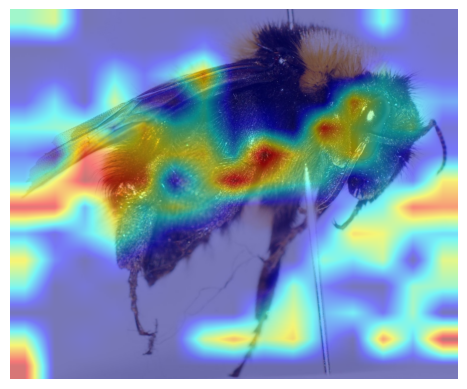

In [13]:
# -----------------------------
# Select one test image
# -----------------------------
image_no = 0
image, lbl, img_path = test_dataset[image_no]

fig, axes = plt.subplots(nrows=1, ncols=1)
plot_cam(model=model.backbone, img_path=img_path, label=lbl, cam_method=cam, transform=test_dataset.transform, ax=axes)

In [14]:
# -----------------------------
# 3️⃣ Inference Function
# -----------------------------
def run_inference(image_path, model, transform):
    image = Image.open(image_path).convert("RGB")
    orig_size = image.size    
    input_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)

        if isinstance(output, dict):
            output = output["out"]

        # Multi-class segmentation
        prob_map = torch.softmax(output, dim=1)

        pred_mask = torch.argmax(prob_map, dim=1, keepdim=True).float()

        pred_mask = torch.nn.functional.interpolate(
            pred_mask,
            size=(orig_size[1], orig_size[0]),
            mode="nearest"
        )

        mask = pred_mask.squeeze().cpu().numpy().astype(np.uint8)

    return np.array(image), mask


# -----------------------------
# 4️⃣ Visualization
# -----------------------------
def visualize_results(image, mask):
    overlay = image.copy()
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title("Original")
    plt.imshow(image)
    plt.axis("off")
    plt.subplot(1, 2, 2)
    plt.title("Overlay")
    plt.imshow(overlay)
    plt.imshow(mask, alpha=0.5)
    plt.axis("off")
    plt.show()

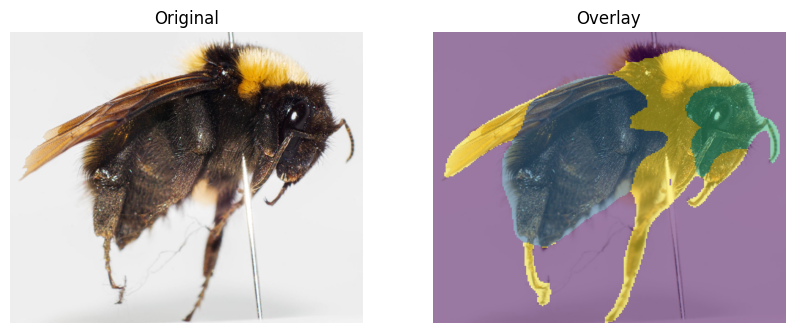

In [15]:
image_no = 0
image, lbl, img_path = test_dataset[image_no]
image, mask = run_inference(image_path=img_path, model=model.seg_module, transform=test_dataset.transform)
visualize_results(image, mask)

In [16]:
image.shape, mask.shape

((1248, 1512, 3), (1248, 1512))

True label: 121
Predicted: 191


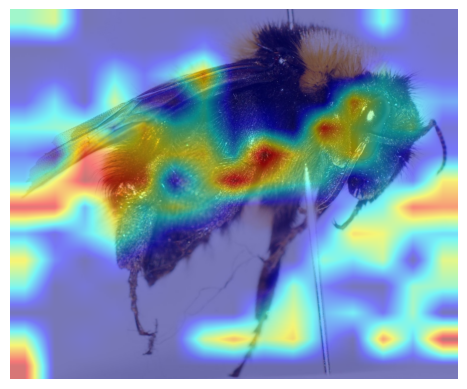

In [17]:
target_layers = [model.backbone.blocks[-1].norm1]
cam = FinerCAM(
    model=model.backbone,
    target_layers=target_layers,
    reshape_transform=reshape_transform
)

# Select one test image
image_no = 0
image, lbl, img_path = test_dataset[image_no]

fig, axes = plt.subplots(nrows=1, ncols=1)
plot_cam(model=model.backbone, img_path=img_path, label=lbl, cam_method=cam, transform=test_dataset.transform, ax=axes)

True label: 121
Predicted: 191


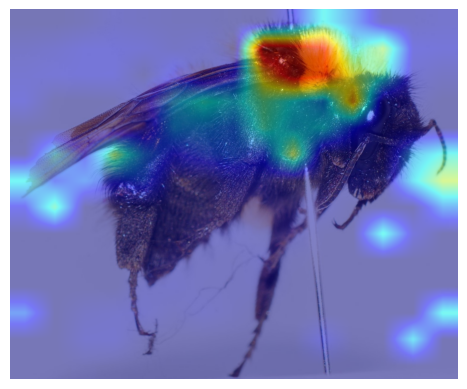

In [18]:
target_layers = [model.backbone.blocks[-3].norm1]
cam = FinerCAM(
    model=model.backbone,
    target_layers=target_layers,
    reshape_transform=reshape_transform
)

# Select one test image
image_no = 0
image, lbl, img_path = test_dataset[image_no]

fig, axes = plt.subplots(nrows=1, ncols=1)
plot_cam(model=model.backbone, img_path=img_path, label=lbl, cam_method=cam, transform=test_dataset.transform, ax=axes)

True label: 121
Predicted: 191


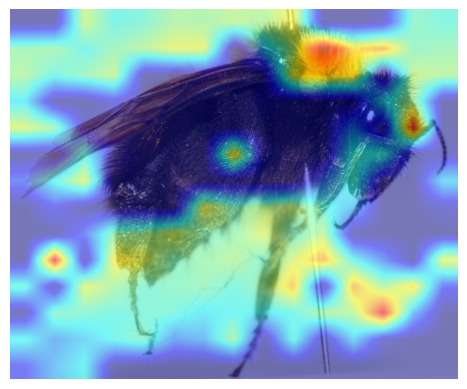

In [19]:
target_layers = [model.backbone.blocks[-4].norm1]
cam = FinerCAM(
    model=model.backbone,
    target_layers=target_layers,
    reshape_transform=reshape_transform
)

# Select one test image
image_no = 0
image, lbl, img_path = test_dataset[image_no]

fig, axes = plt.subplots(nrows=1, ncols=1)
plot_cam(model=model.backbone, img_path=img_path, label=lbl, cam_method=cam, transform=test_dataset.transform, ax=axes)

True label: 121
Predicted: 191


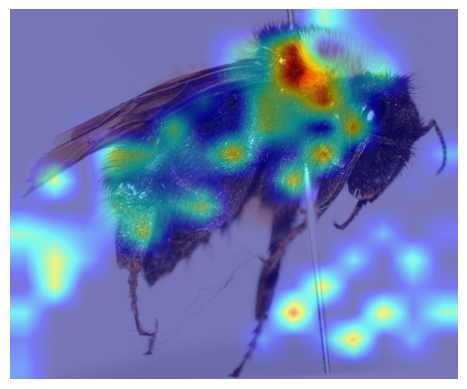

In [20]:
target_layers = [model.backbone.blocks[-6].norm1]
cam = FinerCAM(
    model=model.backbone,
    target_layers=target_layers,
    reshape_transform=reshape_transform
)

# Select one test image
image_no = 0
image, lbl, img_path = test_dataset[image_no]

fig, axes = plt.subplots(nrows=1, ncols=1)
plot_cam(model=model.backbone, img_path=img_path, label=lbl, cam_method=cam, transform=test_dataset.transform, ax=axes)

True label: 121
Predicted: 191


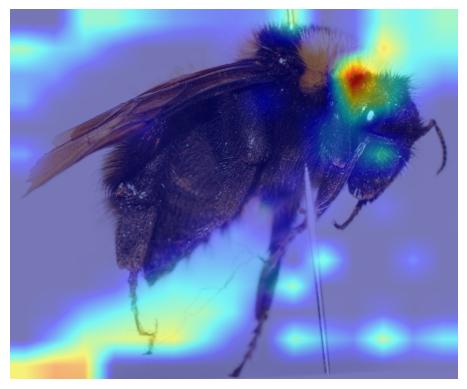

In [21]:
# Also checking norm2
target_layers = [model.backbone.blocks[-6].norm2]
cam = FinerCAM(
    model=model.backbone,
    target_layers=target_layers,
    reshape_transform=reshape_transform
)

# Select one test image
image_no = 0
image, lbl, img_path = test_dataset[image_no]

fig, axes = plt.subplots(nrows=1, ncols=1)
plot_cam(model=model.backbone, img_path=img_path, label=lbl, cam_method=cam, transform=test_dataset.transform, ax=axes)

True label: 121
Predicted: 191


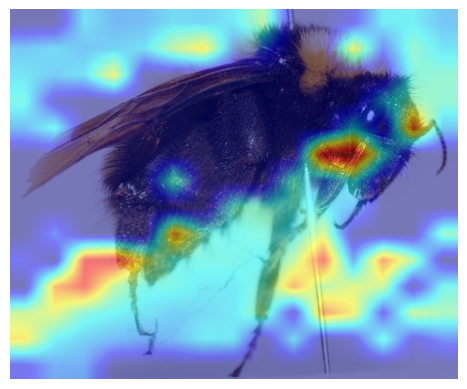

In [22]:
# Also checking norm2
target_layers = [model.backbone.blocks[-3].norm2]
cam = FinerCAM(
    model=model.backbone,
    target_layers=target_layers,
    reshape_transform=reshape_transform
)

# Select one test image
image_no = 0
image, lbl, img_path = test_dataset[image_no]

fig, axes = plt.subplots(nrows=1, ncols=1)
plot_cam(model=model.backbone, img_path=img_path, label=lbl, cam_method=cam, transform=test_dataset.transform, ax=axes)

True label: 121
Predicted: 191


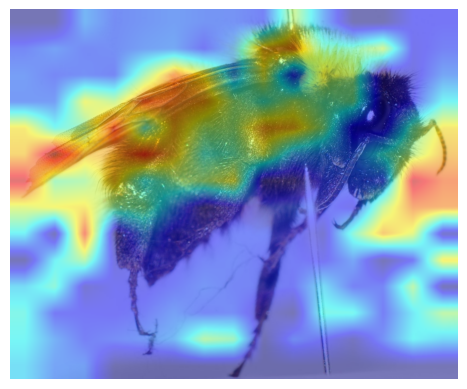

In [23]:
# Also checking norm2
target_layers = [model.backbone.blocks[-1].norm2]
cam = FinerCAM(
    model=model.backbone,
    target_layers=target_layers,
    reshape_transform=reshape_transform
)

# Select one test image
image_no = 0
image, lbl, img_path = test_dataset[image_no]

fig, axes = plt.subplots(nrows=1, ncols=1)
plot_cam(model=model.backbone, img_path=img_path, label=lbl, cam_method=cam, transform=test_dataset.transform, ax=axes)

Average over multiple blocks

True label: 121
Predicted: 191


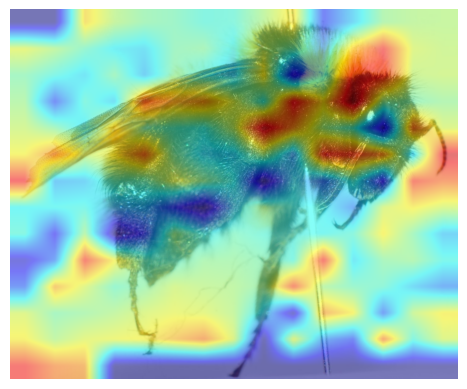

In [25]:
# Also checking norm2
target_layers = [model.backbone.blocks[-i].norm2 for i in [1, 3, 4, 6]]
cam = FinerCAM(
    model=model.backbone,
    target_layers=target_layers,
    reshape_transform=reshape_transform
)

# Select one test image
image_no = 0
image, lbl, img_path = test_dataset[image_no]

fig, axes = plt.subplots(nrows=1, ncols=1)
plot_cam(model=model.backbone, img_path=img_path, label=lbl, cam_method=cam, transform=test_dataset.transform, ax=axes)

True label: 121
Predicted: 191


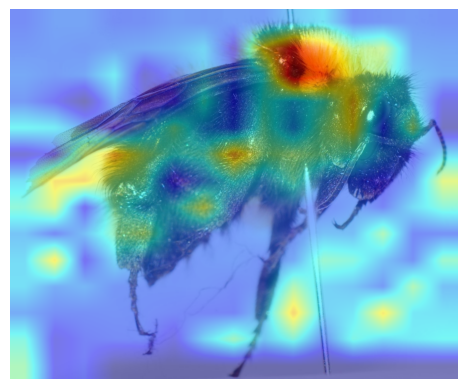

In [27]:
# checking norm1
target_layers = [model.backbone.blocks[-i].norm1 for i in [1, 3, 4, 6]]
cam = FinerCAM(
    model=model.backbone,
    target_layers=target_layers,
    reshape_transform=reshape_transform
)

# Select one test image
image_no = 0
image, lbl, img_path = test_dataset[image_no]

fig, axes = plt.subplots(nrows=1, ncols=1)
plot_cam(model=model.backbone, img_path=img_path, label=lbl, cam_method=cam, transform=test_dataset.transform, ax=axes)

In [ ]:
target_layers = [model.backbone.blocks[-1].norm1]
cam = FinerCAM(
    model=model.backbone,
    target_layers=target_layers,
    reshape_transform=reshape_transform
)

# Select one test image
image_no = 0
image, lbl, img_path = test_dataset[image_no]

fig, axes = plt.subplots(nrows=1, ncols=1)
plot_cam(model=model.backbone, img_path=img_path, label=lbl, cam_method=cam, transform=test_dataset.transform, ax=axes)

In [ ]:
device = torch.device(f"cuda:{DEVICE_ID}")
state_dict = torch.load(MODEL_WEIGHTS, map_location=device)
criterion = nn.CrossEntropyLoss()  #label_smoothing=0.1)
model = DeepShapeFusionModel(num_classes=num_classes, shape_embed_dim=512)
model.to(device)
model.load_state_dict(state_dict)
model.eval()